In [29]:
import pandas as pd
import numpy as np

# --- 1. 配置与读取 ---
input_file = 'query.csv'
output_file = 'all_magtype_cumulative_statistics.csv'
df = pd.read_csv(input_file)

# --- 2. 基础清洗与准备 ---
# 确保 magType 没有缺失值，方便统计
df['magType'] = df['magType'].fillna('Unknown')

# 仅保留震级 >= 5.0 的原始数据
df_filtered = df[df['mag'] >= 5.0].copy()

# 动态获取数据中存在的所有震级类型，并进行排序（美观）
all_mag_types = sorted(df_filtered['magType'].unique().tolist())

# --- 3. 定义累积梯度 ---
mag_min = 5.0
mag_max = df_filtered['mag'].max() if not df_filtered.empty else 10.0
# 生成阈值序列: 5.0, 5.5, 6.0 ... 
thresholds = np.arange(mag_min, mag_max + 0.5, 0.5)

# --- 4. 构建累积统计数据 ---
cumulative_data = []

for t in thresholds:
    # 筛选出所有震级 >= t 的数据
    subset = df_filtered[df_filtered['mag'] >= t]
    
    # 统计该阈值下各类型的数量
    counts = subset['magType'].value_counts()
    
    # 构建当前行的数据字典
    row = {
        'magnitude_threshold': f'>= {t:.1f}',
        'Total_Count': len(subset)
    }
    
    # 将所有震级类型的统计加入字典
    for m_type in all_mag_types:
        row[m_type] = counts.get(m_type, 0)
    
    cumulative_data.append(row)

# 转换为 DataFrame
result_table = pd.DataFrame(cumulative_data)

# 重新排序列：阈值、总计、然后是各震级类型
cols = ['magnitude_threshold', 'Total_Count'] + all_mag_types
result_table = result_table[cols]

# --- 5. 输出到命令行 ---
print("\n=== 正在生成全震级类型累积统计报表 ===")
print("(每一行代表震级大于等于该阈值的地震总数)")
pd.set_option('display.max_columns', None)  # 确保所有列都打印出来
print(result_table.to_string(index=False))

# --- 6. 保存文件 ---
result_table.to_csv(output_file, index=False)

print("\n" + "-"*40)
print(f"成功！统计结果（包含 {len(all_mag_types)} 种震级类型）已保存至: {output_file}")


=== 正在生成全震级类型累积统计报表 ===
(每一行代表震级大于等于该阈值的地震总数)
magnitude_threshold  Total_Count  Md  Ml  m   mb  ml  ms  ms_20  mw  mwb  mwc  mwp  mwr  mww
             >= 5.0        19849   1   1  5 8865  49   9      2 275 1007 3177    6  295 6157
             >= 5.5         5302   0   1  0  391   8   8      0  54  523  699    3   23 3592
             >= 6.0         1614   0   0  0   55   2   1      0  19   45  156    0    1 1335
             >= 6.5          518   0   0  0    4   1   1      0  10    7   61    0    0  434
             >= 7.0          169   0   0  0    0   0   0      0   6    0   24    0    0  139
             >= 7.5           59   0   0  0    0   0   0      0   2    0    8    0    0   49
             >= 8.0           11   0   0  0    0   0   0      0   1    0    1    0    0    9
             >= 8.5            3   0   0  0    0   0   0      0   1    0    0    0    0    2
             >= 9.0            1   0   0  0    0   0   0      0   0    0    0    0    0    1
             >= 9.5    

In [13]:
import pandas as pd
import numpy as np

# --- 1. 配置与读取 ---
input_file = 'query.csv'
output_file = 'mw_magnitude_statistics.csv'
df = pd.read_csv(input_file)

# --- 2. 筛选 Mw 家族数据 ---
# 定义矩震级家族成员
mw_family = ['mw', 'mww', 'mwc', 'mwb', 'mwp', 'mwr']

# 筛选：震级 >= 5.0 且属于 Mw 家族
df_mw = df[(df['mag'] >= 5.0) & (df['magType'].isin(mw_family))].copy()

# --- 3. 梯度划分 ---
# 动态计算区间，步长为 0.5
mag_min = 5.0
mag_max = np.ceil(df_mw['mag'].max()) if not df_mw.empty else 10.0
bins = np.arange(mag_min, mag_max + 0.5, 0.5)

# 进行切分 (left-closed: [5.0, 5.5))
df_mw['magnitude_range'] = pd.cut(df_mw['mag'], bins=bins, right=False)

# --- 4. 生成统计透视表 ---
result_table = pd.pivot_table(
    df_mw, 
    values='mag', 
    index='magnitude_range', 
    columns='magType', 
    aggfunc='count', 
    fill_value=0,
    observed=False
)

# 计算这一行的总计 (Total)，让报表更完整
result_table['Total_Mw'] = result_table.sum(axis=1)

# --- 5. 输出到命令行 ---
pd.set_option('display.expand_frame_repr', False)
print("\n=== 正在生成 Mw 统计报表 ===")
print(result_table)

# --- 6. 保存到新的 CSV 文件 ---
# reset_index() 是为了让 'magnitude_range' 变成 CSV 的第一列，而不是索引名
result_table.reset_index().to_csv(output_file, index=False)

print("\n" + "-"*40)
print(f"成功！结果已保存至: {output_file}")
print(f"总计统计地震条数: {len(df_mw)}")


=== 正在生成 Mw 统计报表 ===
magType           mw  mwb   mwc  mwp  mwr   mww  Total_Mw
magnitude_range                                          
[5.0, 5.5)       221  484  2478    3  272  2565      6023
[5.5, 6.0)        35  478   543    3   22  2257      3338
[6.0, 6.5)         9   38    95    0    1   901      1044
[6.5, 7.0)         4    7    37    0    0   295       343
[7.0, 7.5)         4    0    16    0    0    90       110
[7.5, 8.0)         1    0     7    0    0    40        48
[8.0, 8.5)         0    0     1    0    0     7         8
[8.5, 9.0)         1    0     0    0    0     1         2
[9.0, 9.5)         0    0     0    0    0     1         1
[9.5, 10.0)        0    0     0    0    0     0         0

----------------------------------------
成功！结果已保存至: mw_magnitude_statistics.csv
总计统计地震条数: 10917


数据处理完成报告：
读取总行数:     19849
过滤掉的行数:   1
保留的行数:     19848
数据保留占比:   99.99%
结果已保存至:   filtered_seismic_data.csv


In [10]:
import pandas as pd
import numpy as np

def generate_seismic_report(input_file):
    # 1. 加载数据
    df = pd.read_csv(input_file, quotechar='"')
    
    # 2. 预处理：统一转小写并过滤目标类型
    df['magType'] = df['magType'].str.lower()
    target_types = ['mw', 'mwb', 'mwc', 'mwp', 'mwr', 'mww']
    
    # 过滤：保留目标类型并剔除 mag 或 magType 为空的行
    df_filtered = df[df['magType'].isin(target_types)].dropna(subset=['mag', 'magType']).copy()

    # 3. 创建震级区间 (Binning)
    # 定义区间边界：从 5.0 到 10.0，步长 0.5
    bins = np.arange(5.0, 10.5, 0.5)
    # 生成区间标签，格式如 [5.0, 5.5)
    labels = [f"[{bins[i]:.1f}, {bins[i+1]:.1f})" for i in range(len(bins)-1)]
    
    # 使用 cut 函数对震级进行分箱
    df_filtered['magnitude_range'] = pd.cut(df_filtered['mag'], bins=bins, labels=labels, right=False)

    # 4. 生成交叉表 (Crosstab)
    report = pd.crosstab(
        df_filtered['magnitude_range'], 
        df_filtered['magType']
    )

    # 5. 补充缺失的列（如果某些类型在数据中完全没出现）
    for m_type in target_types:
        if m_type not in report.columns:
            report[m_type] = 0
            
    # 按要求调整列顺序
    report = report[target_types]

    # 6. 计算横向总计 (Total_Mw)
    report['Total_Mw'] = report.sum(axis=1)

    # 7. 打印输出
    print("\n" + "="*60)
    print("地震数据震级分布统计报表")
    print("="*60)
    print(report.to_string())
    print("="*60)

    # 可选：保存报表到 CSV
    report.to_csv('seismic_distribution_report.csv', encoding='utf-8-sig')

if __name__ == "__main__":
    generate_seismic_report('query.csv')


地震数据震级分布统计报表
magType           mw  mwb   mwc  mwp  mwr   mww  Total_Mw
magnitude_range                                          
[5.0, 5.5)       205  481  2331    1  268  2035      5321
[5.5, 6.0)        30  463   494    3   21  2037      3048
[6.0, 6.5)         9   36    84    0    1   829       959
[6.5, 7.0)         3    6    34    0    0   277       320
[7.0, 7.5)         4    0    14    0    0    86       104
[7.5, 8.0)         1    0     7    0    0    37        45
[8.0, 8.5)         0    0     1    0    0     7         8
[8.5, 9.0)         1    0     0    0    0     1         2
[9.0, 9.5)         0    0     0    0    0     1         1


In [24]:
import pandas as pd
import numpy as np

# --- 1. 配置与读取 ---
input_file = 'query.csv'
output_file = 'mw_cumulative_statistics.csv'
df = pd.read_csv(input_file)

# --- 2. 筛选 Mw 家族数据 ---
mw_family = ['mw', 'mww', 'mwc', 'mwb', 'mwp', 'mwr']
# 预筛选：只要属于 Mw 家族且 >= 5.0 的原始数据
df_mw = df[(df['mag'] >= 5.0) & (df['magType'].isin(mw_family))].copy()

# --- 3. 定义累积梯度 ---
mag_min = 5.0
mag_max = df_mw['mag'].max() if not df_mw.empty else 10.0
# 生成阈值序列: 5.0, 5.5, 6.0 ... 
thresholds = np.arange(mag_min, mag_max + 0.5, 0.5)

# --- 4. 构建累积统计数据 ---
cumulative_data = []

for t in thresholds:
    # 筛选出所有震级 >= t 的数据
    subset = df_mw[df_mw['mag'] >= t]
    
    # 统计该阈值下各类型的数量
    counts = subset['magType'].value_counts()
    
    # 构建当前行的数据字典
    row = {
        'magnitude_threshold': f'>= {t:.1f}',
        'Total_Mw': len(subset)
    }
    # 将各个 magType 的统计加入字典
    for m_type in mw_family:
        row[m_type] = counts.get(m_type, 0)
    
    cumulative_data.append(row)

# 转换为 DataFrame
result_table = pd.DataFrame(cumulative_data)

# 调整列顺序，让阈值和总计排在前面
cols = ['magnitude_threshold', 'Total_Mw'] + mw_family
result_table = result_table[cols]

# --- 5. 输出到命令行 ---
print("\n=== 正在生成 Mw 累积统计报表 ===")
print("(每一行代表震级大于等于该阈值的地震总数)")
print(result_table.to_string(index=False))

# --- 6. 保存文件 ---
result_table.to_csv(output_file, index=False)

print("\n" + "-"*40)
print(f"成功！累积统计结果已保存至: {output_file}")


=== 正在生成 Mw 累积统计报表 ===
(每一行代表震级大于等于该阈值的地震总数)
magnitude_threshold  Total_Mw  mw  mww  mwc  mwb  mwp  mwr
             >= 5.0     10917 275 6157 3177 1007    6  295
             >= 5.5      4894  54 3592  699  523    3   23
             >= 6.0      1556  19 1335  156   45    0    1
             >= 6.5       512  10  434   61    7    0    0
             >= 7.0       169   6  139   24    0    0    0
             >= 7.5        59   2   49    8    0    0    0
             >= 8.0        11   1    9    1    0    0    0
             >= 8.5         3   1    2    0    0    0    0
             >= 9.0         1   0    1    0    0    0    0
             >= 9.5         0   0    0    0    0    0    0

----------------------------------------
成功！累积统计结果已保存至: mw_cumulative_statistics.csv


In [21]:
import pandas as pd

# --- 1. 配置 ---
input_file = 'filtered_seismic_data.csv'
output_file = 'cleaned_earthquake_data.csv'
error_threshold = 0.3

# --- 2. 读取数据 ---
df = pd.read_csv(input_file)

# 记录原始数据条数
original_count = len(df)

# --- 3. 执行筛选 ---
# 逻辑：保留 (误差 <= 0.2) 的数据
# 如果你想同时保留那些“没有误差记录(NaN)”的数据，可以使用：
df_cleaned = df[(df['magError'] <= error_threshold) | (df['magError'].isna())]

# 严格筛选：只保留有数值且 <= 0.2 的数据
#df_cleaned = df[df['magError'] <= error_threshold].copy()

# --- 4. 输出统计信息 ---
removed_count = original_count - len(df_cleaned)
print(f"=== 数据清洗完成 ===")
print(f"原始记录总数: {original_count}")
print(f"剔除记录数量: {removed_count} (magError > {error_threshold} 或为 NaN)")
print(f"保留记录数量: {len(df_cleaned)}")

# --- 5. 保存结果 ---
df_cleaned.to_csv(output_file, index=False)
print(f"\n结果已保存至: {output_file}")

=== 数据清洗完成 ===
原始记录总数: 10917
剔除记录数量: 4 (magError > 0.3 或为 NaN)
保留记录数量: 10913

结果已保存至: cleaned_earthquake_data.csv


In [22]:
import pandas as pd
import numpy as np

# --- 1. 配置与读取 ---
input_file = 'cleaned_earthquake_data.csv'
output_file = 'mw_cumulative_statistics.csv'
df = pd.read_csv(input_file)

# --- 2. 筛选 Mw 家族数据 ---
mw_family = ['mw', 'mww', 'mwc', 'mwb', 'mwp', 'mwr']
# 预筛选：只要属于 Mw 家族且 >= 5.0 的原始数据
df_mw = df[(df['mag'] >= 5.0) & (df['magType'].isin(mw_family))].copy()

# --- 3. 定义累积梯度 ---
mag_min = 5.0
mag_max = df_mw['mag'].max() if not df_mw.empty else 10.0
# 生成阈值序列: 5.0, 5.5, 6.0 ... 
thresholds = np.arange(mag_min, mag_max + 0.5, 0.5)

# --- 4. 构建累积统计数据 ---
cumulative_data = []

for t in thresholds:
    # 筛选出所有震级 >= t 的数据
    subset = df_mw[df_mw['mag'] >= t]
    
    # 统计该阈值下各类型的数量
    counts = subset['magType'].value_counts()
    
    # 构建当前行的数据字典
    row = {
        'magnitude_threshold': f'>= {t:.1f}',
        'Total_Mw': len(subset)
    }
    # 将各个 magType 的统计加入字典
    for m_type in mw_family:
        row[m_type] = counts.get(m_type, 0)
    
    cumulative_data.append(row)

# 转换为 DataFrame
result_table = pd.DataFrame(cumulative_data)

# 调整列顺序，让阈值和总计排在前面
cols = ['magnitude_threshold', 'Total_Mw'] + mw_family
result_table = result_table[cols]

# --- 5. 输出到命令行 ---
print("\n=== 正在生成 Mw 累积统计报表 ===")
print("(每一行代表震级大于等于该阈值的地震总数)")
print(result_table.to_string(index=False))

# --- 6. 保存文件 ---
result_table.to_csv(output_file, index=False)

print("\n" + "-"*40)
print(f"成功！累积统计结果已保存至: {output_file}")


=== 正在生成 Mw 累积统计报表 ===
(每一行代表震级大于等于该阈值的地震总数)
magnitude_threshold  Total_Mw  mw  mww  mwc  mwb  mwp  mwr
             >= 5.0     10913 272 6157 3177 1007    5  295
             >= 5.5      4891  51 3592  699  523    3   23
             >= 6.0      1555  18 1335  156   45    0    1
             >= 6.5       512  10  434   61    7    0    0
             >= 7.0       169   6  139   24    0    0    0
             >= 7.5        59   2   49    8    0    0    0
             >= 8.0        11   1    9    1    0    0    0
             >= 8.5         3   1    2    0    0    0    0
             >= 9.0         1   0    1    0    0    0    0
             >= 9.5         0   0    0    0    0    0    0

----------------------------------------
成功！累积统计结果已保存至: mw_cumulative_statistics.csv


拟合结果:
a 值 (活动性): 9.3671
b 值 (斜率): 1.0343
相关系数 R^2: 0.9949


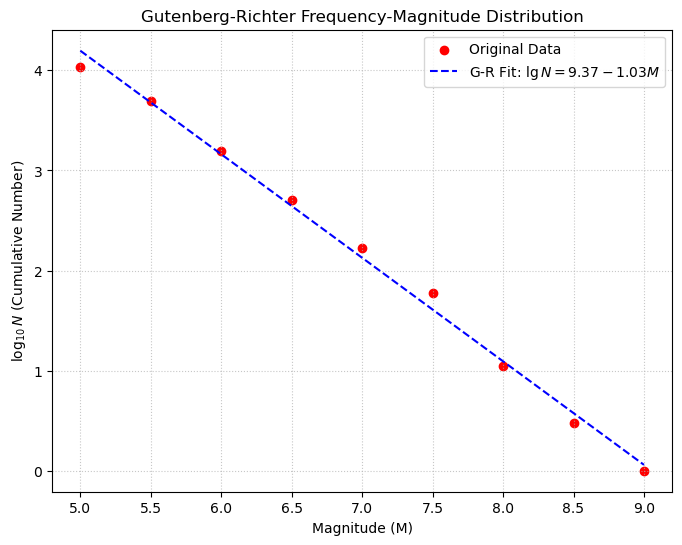

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1. 准备数据
# 震级阈值 M
magnitude_threshold = np.array([5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0])
# 累积频次 Total_Mw (对应上述 M，剔除频次为0的 9.5级)
total_mw = np.array([10913, 4891, 1555, 512, 169, 59, 11, 3, 1])

# 2. 对累积频次取以10为底的对数
log_N = np.log10(total_mw)

# 3. 进行线性回归拟合 (lgN = a - bM -> y = intercept + slope * x)
# 注意：slope 对应的是 -b
slope, intercept, r_value, p_value, std_err = linregress(magnitude_threshold, log_N)

a = intercept
b = -slope

print(f"拟合结果:")
print(f"a 值 (活动性): {a:.4f}")
print(f"b 值 (斜率): {b:.4f}")
print(f"相关系数 R^2: {r_value**2:.4f}")

# 4. 绘图可视化
plt.figure(figsize=(8, 6))
plt.scatter(magnitude_threshold, log_N, color='red', label='Original Data')
plt.plot(magnitude_threshold, intercept + slope * magnitude_threshold, 
         'b--', label=f'G-R Fit: $\lg N = {a:.2f} - {b:.2f}M$')

plt.xlabel('Magnitude (M)')
plt.ylabel('$\log_{10} N$ (Cumulative Number)')
plt.title('Gutenberg-Richter Frequency-Magnitude Distribution')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

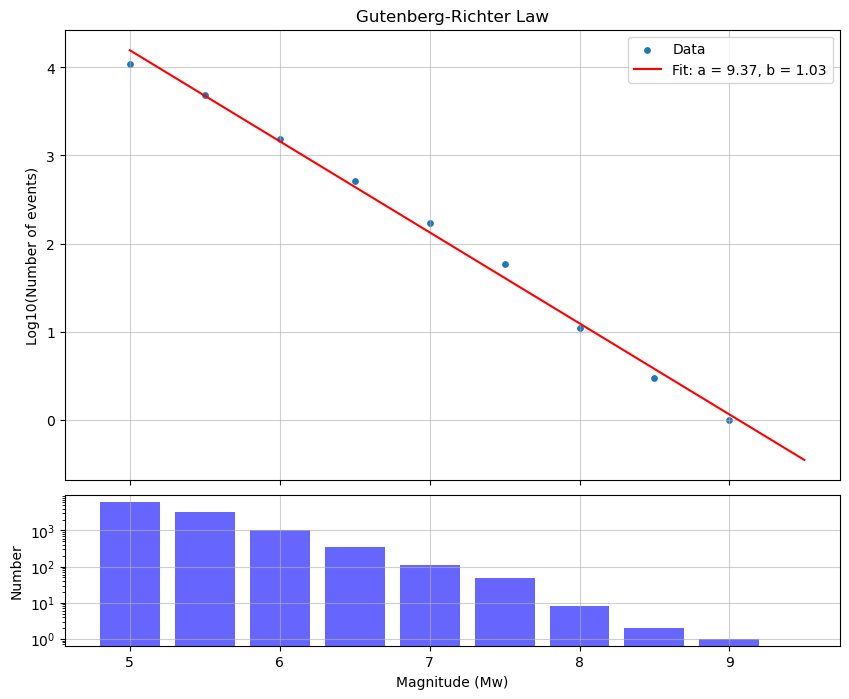

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1. 原始数据 (根据你提供的表格)
mag_threshold = np.array([5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0])
total_mw = np.array([10913, 4891, 1555, 512, 169, 59, 11, 3, 1])

# 2. 计算非累积频次 (用于绘制下方的直方图)
# 差分计算：每个震级分段内的地震数量
discrete_counts = np.abs(np.diff(total_mw, append=0)) 

# 3. 线性回归拟合 (G-R Law: log10(N) = a - bM)
log_N = np.log10(total_mw)
slope, intercept, r_value, p_value, std_err = linregress(mag_threshold, log_N)
a, b = intercept, -slope

# 4. 创建画布，设置双子图比例
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.05) # 减少子图间距

# --- 上图：G-R Law 拟合图 ---
ax1.scatter(mag_threshold, log_N, s=15, color='#1f77b4', label='Data')
# 绘制拟合线
m_fit = np.linspace(5.0, 9.5, 100)
n_fit = intercept + slope * m_fit
ax1.plot(m_fit, n_fit, color='red', label=f'Fit: a = {a:.2f}, b = {b:.2f}')

ax1.set_ylabel('Log10(Number of events)')
ax1.set_title('Gutenberg-Richter Law')
ax1.grid(True, linestyle='-', alpha=0.6)
ax1.legend()

# --- 下图：频次直方图 ---
# 使用 step 或 bar 模拟直方图效果
ax2.bar(mag_threshold, discrete_counts, width=0.4, color='blue', alpha=0.6)
ax2.set_yscale('log') # 通常频率图使用对数坐标
ax2.set_xlabel('Magnitude (Mw)')
ax2.set_ylabel('Number')
ax2.grid(True, linestyle='-', alpha=0.6)

plt.show()

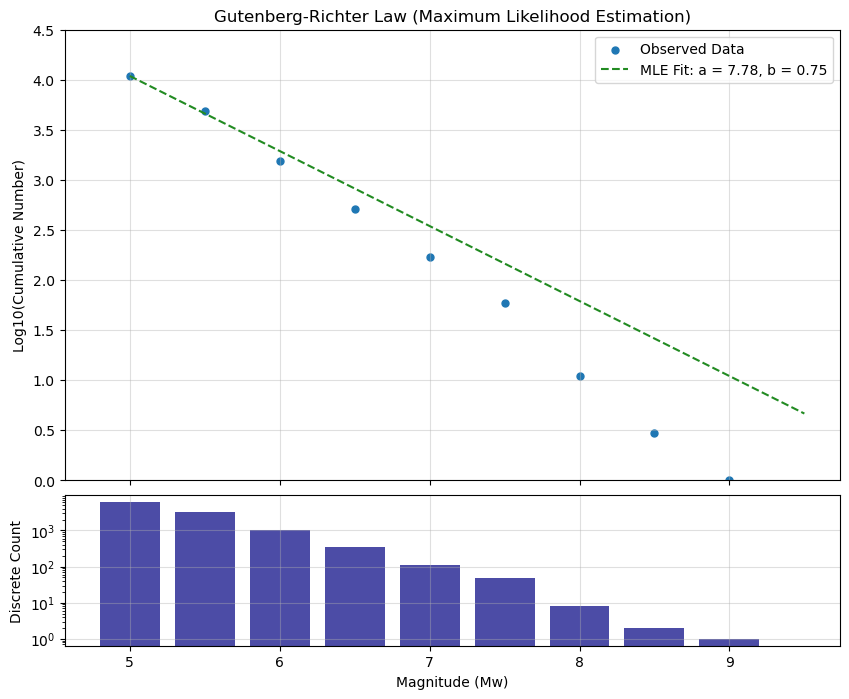

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 原始数据 (根据提供的表格)
mag_threshold = np.array([5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0])
total_mw = np.array([10913, 4891, 1555, 512, 169, 59, 11, 3, 1])

# 2. 计算非累积频次 (用于下方直方图及还原样本)
discrete_counts = np.abs(np.diff(total_mw, append=0))

# 3. 极大似然法 (MLE) 计算 b 值
# 还原伪样本以计算平均震级 Mean Magnitude
m_samples = []
for m, count in zip(mag_threshold, discrete_counts):
    m_samples.extend([m] * int(count))
m_samples = np.array(m_samples)

m_mean = np.mean(m_samples)
m_min = mag_threshold[0]
delta_m = 0.5  # 震级步长

# Aki (1965) MLE 公式: b = log10(e) / (M_avg - (M_min - delta_m/2))
b_mle = np.log10(np.exp(1)) / (m_mean - (m_min - delta_m / 2))
# 计算 a 值: 令拟合线在 M_min 处穿过观测到的总数 log10(N)
a_mle = np.log10(total_mw[0]) + b_mle * m_min

# 4. 创建画布 (保持原代码双子图比例)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.05)

# --- 上图：G-R Law MLE 拟合图 ---
log_N = np.log10(total_mw)
ax1.scatter(mag_threshold, log_N, s=25, color='#1f77b4', label='Observed Data')

# 绘制 MLE 拟合线
m_fit = np.linspace(5.0, 9.5, 100)
log_n_fit = a_mle - b_mle * m_fit
ax1.plot(m_fit, log_n_fit, color='forestgreen', linestyle='--', 
         label=f'MLE Fit: a = {a_mle:.2f}, b = {b_mle:.2f}')

ax1.set_ylabel('Log10(Cumulative Number)')
ax1.set_title('Gutenberg-Richter Law (Maximum Likelihood Estimation)')
ax1.set_ylim(0, 4.5) # 根据数据范围微调
ax1.grid(True, linestyle='-', alpha=0.4)
ax1.legend()

# --- 下图：频次直方图 ---
ax2.bar(mag_threshold, discrete_counts, width=0.4, color='navy', alpha=0.7)
ax2.set_yscale('log') 
ax2.set_xlabel('Magnitude (Mw)')
ax2.set_ylabel('Discrete Count')
ax2.grid(True, linestyle='-', alpha=0.4)

plt.show()